# BioJEPA v0.6 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from biojepa_v0_6 import BioJepa, BioJepaConfig
from dataloader_v0_6 import PretrainLoader, AlignmentLoader, TrainingLoader
from training_v0_6 import create_model, load_feature_banks, run_pretraining, run_alignment, run_full_training, train_linear_decoder
from config_v0_6 import PretrainConfig, AlignmentConfig, FullTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_pretraining_evals, run_alignment_evals, run_full_model_evals, save_report

## Device & Paths

In [2]:
def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    print(f'using {device}')
    return device

torch.manual_seed(1337)
random.seed(1337)
torch.set_float32_matmul_precision('high')

device = get_device()

data_root = Path('/Users/djemec/data/jepa/v0_6')
ref_root = Path('/Users/djemec/data/jepa/reference_data')

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoints',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cpu


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=2,
    heads=2,
    embed_dim=8,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.6,
    gaussian_scale=2.0,
    film_linear_multiple=1.0,
    sim_coeff=25.0,
    std_coeff=25.0,
    cov_coeff=1.0,
    pert_latent_dim= 8,#320,
    pert_mode_dim= 8, #64
)

# Training configs
pt_cfg = PretrainConfig(epochs=1, lr=1e-3, batch_size=32) #n_steps=1000,,
align_cfg = AlignmentConfig(epochs=100, lr=4e-3, batch_size=32)
full_cfg = FullTrainingConfig(epochs=1, predictor_lr=1e-3, batch_size=32) # epochs=1,
decoder_cfg = DecoderConfig(epochs=1, lr=1e-3, batch_size=16) # epochs=1,

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1024])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 82,002
ACpredictor: 82,672
PerturbationComposer: 26,560


### Load pretraining model from checkpoint (for resuming)

In [5]:
# checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_6_align_final.pt'
# with torch.serialization.safe_globals([BioJepaConfig]):
#     checkpoint = torch.load(checkpoint_path)

# keys = model.load_state_dict(checkpoint['model'])
# keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Pretraining

In [ ]:
decompress_npz(data_cfg.data_root / 'pretraining')

In [ ]:
pt_train_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pretraining', 
    device=device )
pt_val_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pretraining', 
    device=device)

In [ ]:
pt_results = run_pretraining(model, pt_train_loader, pt_val_loader, pt_cfg, device, data_cfg.checkpoint_dir, model_cfg)


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Pretraining Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Pretraining Evals

In [ ]:
eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim, 
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': pt_cfg.batch_size
})
pt_eval_results = run_pretraining_evals(eval_ctx)

save_report(pt_eval_results, data_cfg.eval_results_dir / 'pretraining_eval_report.json')
pt_eval_results

In [ ]:
compress_npz(data_cfg.data_root / 'pretraining')

In [ ]:
del pt_train_loader, pt_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 2: Perturbation Alignment

In [ ]:
align_train_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250)
align_val_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

In [ ]:
align_results = run_alignment(model, align_train_loader, align_val_loader, seq_banks, target_bank, align_cfg, device, data_cfg.checkpoint_dir)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Alignment Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Alignment Evals

In [ ]:
align_eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': align_cfg.batch_size
})
align_eval_results = run_alignment_evals(align_eval_ctx)

save_report(align_eval_results, data_cfg.eval_results_dir / 'alignment_eval_report.json')
align_eval_results

In [ ]:
del align_train_loader, align_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 3: Full Training

In [6]:
train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device)
val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'training', 
    device=device)

full_results = run_full_training(model, train_loader, val_loader, seq_banks, target_bank, full_cfg, device, data_cfg.checkpoint_dir)

found 976 shards for split train
found 62 shards for split val
Full training: 2498560 samples, 78080 steps/epoch, 78080 total steps
Step 0 | val loss: 112.0049
Step 0 | Loss: 77.95670 | LR: 4.00e-05
Step 25 | Loss: 55.57316 | LR: 4.01e-05
Step 50 | Loss: 47.14806 | LR: 4.04e-05
Step 75 | Loss: 48.18836 | LR: 4.09e-05
Step 100 | val loss: 104.4187
Step 100 | Loss: 47.20977 | LR: 4.16e-05
Step 125 | Loss: 44.03183 | LR: 4.25e-05
Step 150 | Loss: 42.55832 | LR: 4.35e-05
Step 175 | Loss: 42.46774 | LR: 4.48e-05
Step 200 | val loss: 101.1197
Step 200 | Loss: 43.57365 | LR: 4.63e-05
Step 225 | Loss: 42.85394 | LR: 4.79e-05
Step 250 | Loss: 41.32214 | LR: 4.98e-05
Step 275 | Loss: 43.38253 | LR: 5.18e-05
Step 300 | val loss: 58.0142
Step 300 | Loss: 41.68803 | LR: 5.40e-05
Step 325 | Loss: 39.88683 | LR: 5.64e-05
Step 350 | Loss: 41.24634 | LR: 5.90e-05
Step 375 | Loss: 40.49098 | LR: 6.18e-05
Step 400 | val loss: 45.0729
Step 400 | Loss: 44.06819 | LR: 6.48e-05
Step 425 | Loss: 43.75866 | LR

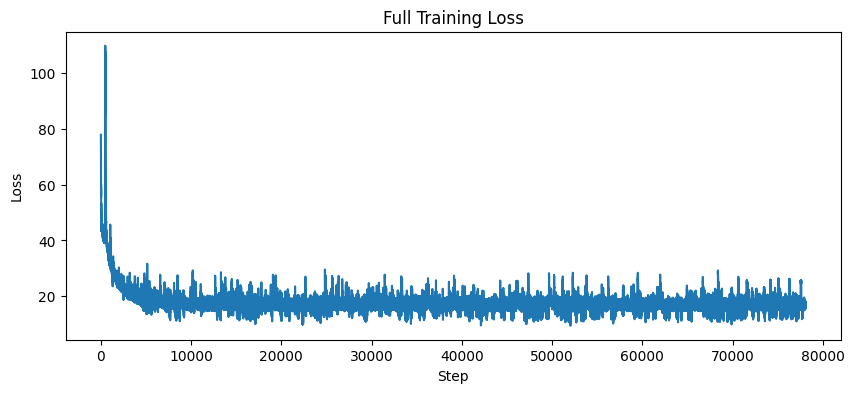

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('Full Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [8]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [9]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'training',
    device=device,
    total_samples=11044)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg)

found 976 shards for split train
found 62 shards for split val
Decoder Step 0 | val loss: 0.8681
Decoder Step 0 | Loss: 0.88872
Decoder Step 25 | Loss: 0.81844
Decoder Step 50 | Loss: 0.79241
Decoder Step 75 | Loss: 0.88222
Decoder Step 100 | val loss: 0.8177
Decoder Step 100 | Loss: 0.81091
Decoder Step 125 | Loss: 0.78587
Decoder Step 150 | Loss: 0.79441
Decoder Step 175 | Loss: 0.79501
Decoder Step 200 | val loss: 0.6087
Decoder Step 200 | Loss: 0.67735
Decoder Step 225 | Loss: 0.55617
Decoder Step 250 | Loss: 0.50167
Decoder Step 275 | Loss: 0.42961
Decoder Step 300 | val loss: 0.3627
Decoder Step 300 | Loss: 0.39357
Decoder Step 325 | Loss: 0.72519
Decoder Step 350 | Loss: 0.68179
Decoder Step 375 | Loss: 0.64627
Decoder Step 400 | val loss: 0.2830
Decoder Step 400 | Loss: 0.64568
Decoder Step 425 | Loss: 0.58546
Decoder Step 450 | Loss: 0.60548
Decoder Step 475 | Loss: 0.56894
Decoder Step 500 | val loss: 0.2256
Decoder Step 500 | Loss: 0.21929
Decoder Step 525 | Loss: 0.23288
De

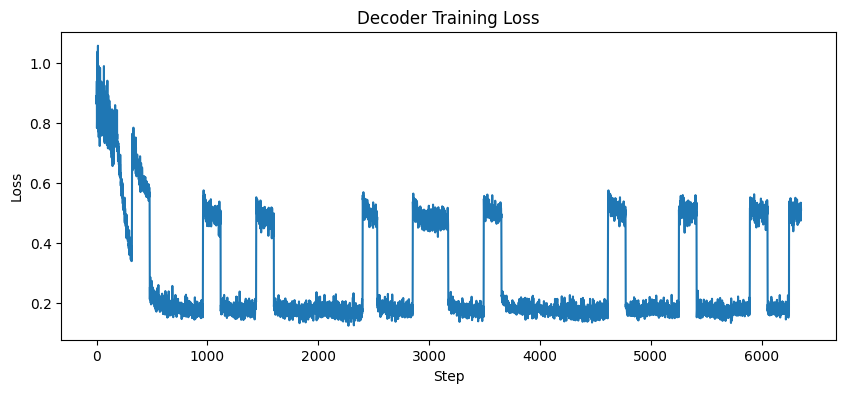

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Full Model Evals

In [11]:
eval_ctx = EvalContext.from_trained_model(model, decoder=decoder, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': full_cfg.batch_size
})
full_eval_results = run_full_model_evals(eval_ctx)

save_report(full_eval_results, data_cfg.eval_results_dir / 'full_model_eval_report.json')
full_eval_results

Using cpu
found 121 shards for split test


Running test inference:   0%|                                                            | 0/1213 [00:00<?, ?it/s]

Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1024])
Loaded target bank: torch.Size([9975, 320])


Running test inference:  31%|███████████████▋                                  | 382/1213 [02:55<07:24,  1.87it/s]/Users/djemec/code/biojepa/evals/evals.py:394: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference: 100%|█████████████████████████████████████████████████| 1213/1213 [09:06<00:00,  2.22it/s]


Aggregated 1074 perturbations, 38816 samples
expression_prediction: MSE=0.2237, R2_all=0.9170
gene_level_analysis: Dir_acc=0.9213, Top50_acc=0.1887


perturbation_retrieval (dna): 100%|██████████████████████████████████████████| 100/100 [4:08:33<00:00, 149.13s/it]


perturbation_retrieval (dna): MRR=0.0007


perturbation_retrieval (chemical): 100%|██████████████████████████████████████████| 13/13 [00:29<00:00,  2.25s/it]


perturbation_retrieval (chemical): MRR=0.0406
uncertainty_calibration: ECE=0.3914, Monotonicity=33.33%
Loading KEGG_2021_Human...
  320 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
Encoded DNA sequences: torch.Size([11643, 8])
Encoded chemical sequences: torch.Size([188, 8])
Encoded protein targets: torch.Size([9975, 8])
action_vector_pathways DNA: sil=-0.34919753670692444
Loaded 10797 v0.6 alignment pairs
moa_matching: Within=0.7085, Between=0.7142, Ratio=0.992x
Saved report to /Users/djemec/data/jepa/v0_6/eval_results/full_model_eval_report.json


{'expression_prediction': {'config': {'test_perturbations': 1074,
   'genes': 10000,
   'test_samples': 38816},
  'sample_level': {'mse': 0.2237197607755661,
   'pearson_r_top20': 0.7256180247553353},
  'perturbation_level': {'r2_all_genes': {'mean': 0.9169986043229449,
    'median': 0.9331819713115692},
   'r2_top50_degs': {'mean': 0.28409426050257197,
    'median': 0.4038368761539459},
   'mse': {'mean': 0.020181218162178993, 'median': 0.016112931072711945}},
  'severity': {'pearson_r': 0.6321840286254883,
   'spearman_r': 0.803454874818998},
  'error_by_magnitude': {'0-0.25': {'mae': 0.08493394404649734,
    'count': 10227953},
   '0.25-0.5': {'mae': 0.2515014708042145, 'count': 450815},
   '0.5-1.0': {'mae': 0.49392005801200867, 'count': 55601},
   '1.0-1.5': {'mae': 0.9943000078201294, 'count': 4810},
   '1.5-2.0': {'mae': 1.4885085821151733, 'count': 603},
   '2.0+': {'mae': 1.99675452709198, 'count': 218}}},
 'gene_level_analysis': {'config': {'test_perturbations': 1074,
   'gen

In [12]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [13]:
print('=== Training Complete ===')
print(f'Pretraining final loss: {pt_results["final_loss"]:.5f}')
print(f'Alignment final loss: {align_results["final_loss"]:.5f}')
print(f'Full training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')

=== Training Complete ===


NameError: name 'pt_results' is not defined